# 01. Boosting

Boosting은 약한 모델을 순서대로 학습하면서 앞 모델의 실수를 뒤 모델이 보완하게 만드는 앙상블 방식임.  
Bagging이 여러 모델을 독립적으로 만드는 방식이라면, Boosting은 모델을 **순차적으로 연결**해 오차를 줄여 나감.

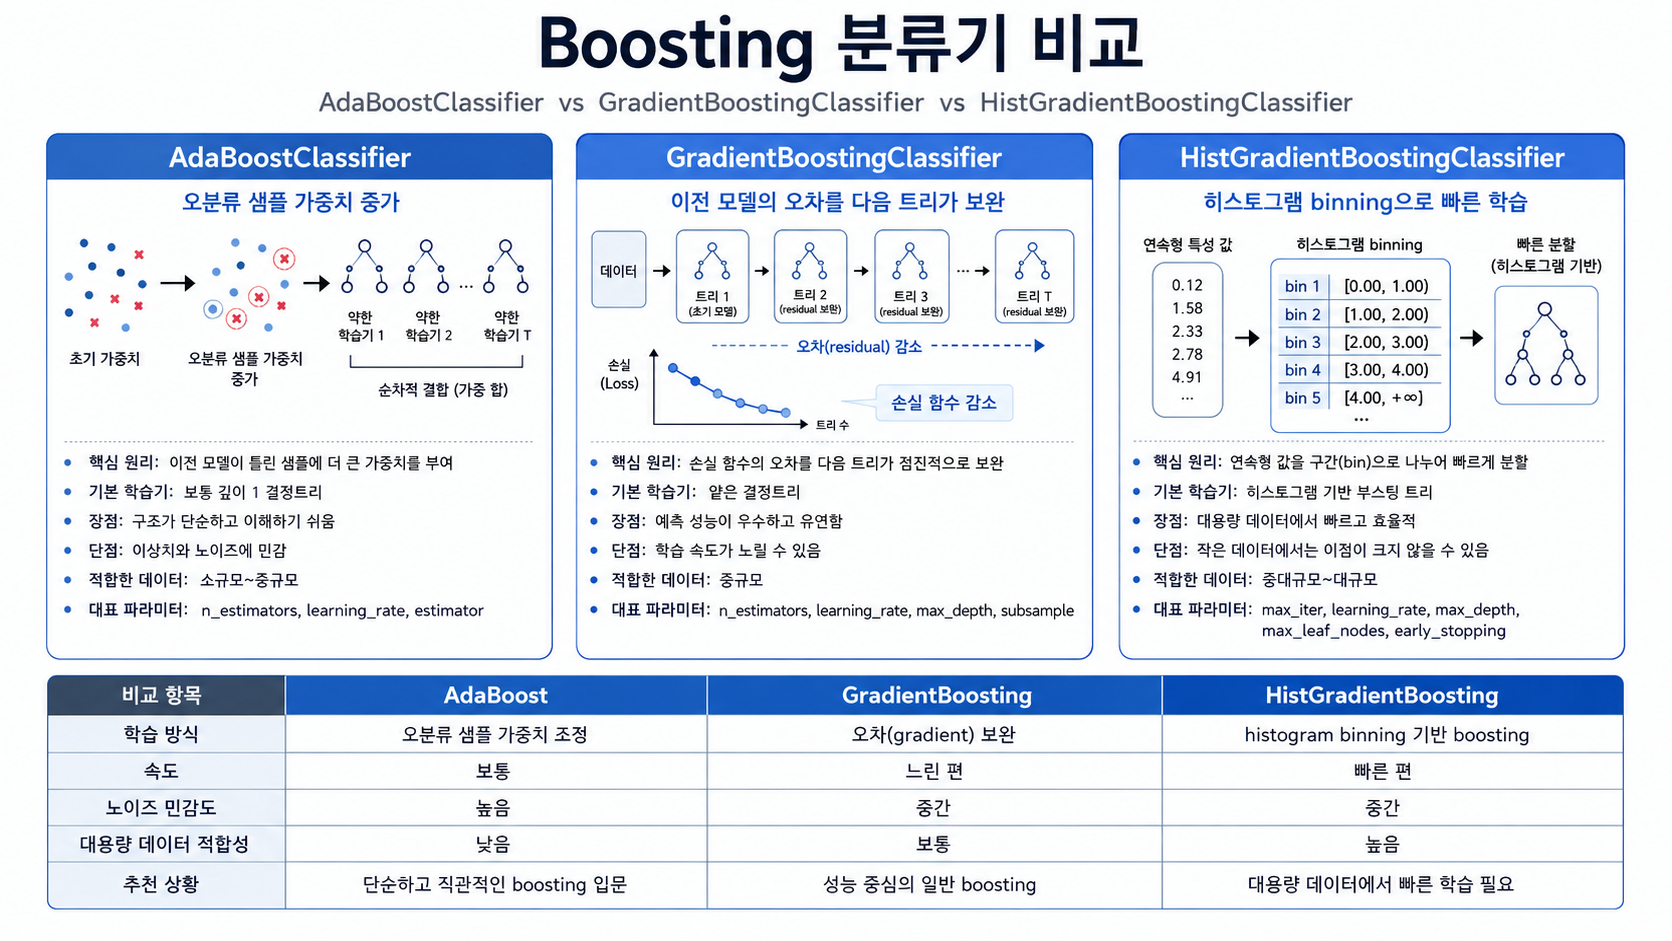


### 01-01. 배우는 이유

- Boosting은 실무와 모델링 대회에서 강력한 성능을 자주 보이는 앙상블 계열임.
- XGBoost, LightGBM, CatBoost 같은 라이브러리도 Gradient Boosting 계열의 발전형임.
- Bagging과 Boosting의 차이를 이해하면 앙상블 모델을 선택하는 기준이 명확해짐.

### 01-02. 어디서 사용하는가?

- 고객 이탈, 불량 탐지, 신용 위험 예측처럼 정형 데이터 분류 문제에서 자주 사용함.
- 가격, 수요량, 매출 예측처럼 정형 데이터 회귀 문제에서도 자주 사용함.
- feature가 많은 표 데이터에서 기본 모델보다 높은 성능이 필요할 때 후보 모델로 자주 검토함.

### 01-03. Bagging과 Boosting 차이

**Bagging**
- 여러 모델을 독립적으로 학습함.
- 서로 다른 bootstrap sample을 사용함.
- 최종 예측은 투표 또는 평균으로 결합함.
- 주로 예측의 흔들림을 줄여 안정성을 높임.

**Boosting**
- 모델을 순차적으로 학습함.
- 앞 모델이 틀린 부분에 더 집중함.
- 여러 약한 모델을 더해 강한 모델을 만듦.
- 성능이 좋을 수 있지만 설정에 따라 과대적합될 수 있음.

### 01-04. 핵심 용어

**Weak learner**
- 성능은 약하지만 빠르고 단순한 기본 모델임.
- Boosting에서는 얕은 결정트리를 자주 사용함.

**learning_rate**
- 각 모델이 최종 예측에 반영되는 정도임.
- 작으면 천천히 학습하고, 보통 더 많은 모델이 필요함.

**n_estimators / max_iter**
- 순차적으로 만들 모델 개수 또는 반복 횟수임.
- 너무 크면 훈련 데이터에 과하게 맞출 수 있음.

**과대적합 확인**
- 학습 점수는 매우 높은데 평가 점수가 낮으면 훈련 데이터에 지나치게 맞춘 상태일 수 있음.
- Boosting은 성능이 강력한 만큼 `learning_rate`, `n_estimators`, `max_depth`를 함께 조절해야 함.


## 02. 실습 환경 준비

- `AdaBoostClassifier`: 이전 모델이 틀린 샘플에 더 큰 가중치를 주며 학습함.
- `GradientBoostingClassifier`: 이전 모델의 오차를 줄이는 방향으로 다음 트리를 학습함.
- `HistGradientBoostingClassifier`: feature를 구간으로 나눠 빠르게 학습하는 Gradient Boosting 모델임.
- `permutation_importance`: feature를 섞었을 때 성능이 얼마나 떨어지는지 보고 중요도를 추정함.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, root_mean_squared_error, r2_score


## 03. 분류 데이터 로드

- Breast Cancer 데이터로 Boosting 분류 모델을 비교함.
- target은 `0=malignant`, `1=benign`임.
- 트리 기반 Boosting 모델은 스케일링 없이 학습할 수 있음.


In [2]:
cancer = load_breast_cancer(as_frame=True)
boost_X = cancer.data
boost_y = cancer.target

print('feature shape:', boost_X.shape)
print('target shape:', boost_y.shape)
print('target 이름:', cancer.target_names)
display(boost_X.head())


feature shape: (569, 30)
target shape: (569,)
target 이름: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
boost_X_train, boost_X_test, boost_y_train, boost_y_test = train_test_split(
    boost_X,
    boost_y,
    test_size=0.2,       # 전체 데이터의 20%를 최종 평가 데이터로 사용
    random_state=42,     # 수업 중 같은 결과가 나오도록 난수 고정
    stratify=boost_y     # 악성/양성 class 비율이 train/test에 비슷하게 유지되도록 분할
)

print('학습 데이터:', boost_X_train.shape, boost_y_train.shape)
print('평가 데이터:', boost_X_test.shape, boost_y_test.shape)
print('target 이름:', cancer.target_names)
display(boost_X.head())

학습 데이터: (455, 30) (455,)
평가 데이터: (114, 30) (114,)
target 이름: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 04. AdaBoostClassifier 학습

- AdaBoost는 앞 모델이 틀린 샘플에 더 큰 가중치를 주며 다음 모델을 학습함.
- 기본적으로 얕은 결정트리를 여러 개 사용함.
- 결과 표에서는 단일 얕은 트리와 AdaBoost의 성능을 비교함.

### 04-01. AdaBoost는 어떻게 학습하는가?

AdaBoost는 깊이 1짜리 트리들을 하나로 합쳐서 하나의 큰 트리로 만드는 방식이 아니다.

학습 과정에서 **깊이 1짜리 트리(Decision Stump, 그루터기 트리)** 를 순차적으로 여러 개 만들고,

최종 예측 시 각 트리의 예측을 **가중 투표**로 결합한다.

1. **초기화**: 처음에는 모든 학습 샘플의 가중치(중요도)를 동일하게 설정.

2. **기본 모델 학습**: 깊이 1짜리 트리 하나가 feature 조건 하나를 찾아 양성/악성을 구분.

3. **샘플 가중치 업데이트**: 그 트리가 틀린 샘플의 가중치는 높이고, 맞춘 샘플의 가중치는 낮춘다.

4. **연쇄 학습**: 다음 트리는 가중치가 높아진(오답 노트에 적힌) 샘플을 더 신경 써서 다시 새로운 조건을 찾음.

5. **트리별 신뢰도 부여**: 각 트리는 자신이 얼마나 잘 맞혔는지(에러율)에 따라 최종 투표에서 쓸 **신뢰도 가중치(발언권)** 를 받는다.

6. **최종 예측 (가중 투표)**: 여러 트리의 예측 결과를 각자가 가진 신뢰도 가중치를 곱해 합산한 후, 최종 결론을 내림.

#### 💡 가중 투표 예시
트리 5개가 다음과 같이 예측하고 각각의 신뢰도 가중치를 가졌다고 가정해 봅시다.

| 트리 | 예측 | 트리 신뢰도 가중치 |
|---|---|---:|
| 트리 1 | 악성 | 0.9 |
| 트리 2 | 양성 | 0.6 |
| 트리 3 | 악성 | 0.4 |
| 트리 4 | 악성 | 0.7 |
| 트리 5 | 양성 | 0.3 |

* **단순 다수결 기준**: 악성(3표) vs 양성(2표) $\rightarrow$ **악성**
* **AdaBoost의 가중 투표 계산**:
  * **악성 예측 팀의 점수 합**: 0.9 + 0.4 + 0.7 = **2.0**
  * **양성 예측 팀의 점수 합**: 0.6 + 0.3 = **0.9**
  * **최종 결론**: 악성 팀의 점수 합(2.0)이 더 크므로, 이 앙상블 모델은 최종적으로 **[악성]**으로 예측합니다.
```text
악성 점수 = 0.9 + 0.4 + 0.7 = 2.0
양성 점수 = 0.6 + 0.3 = 0.9
최종 예측 = 악성
```

즉, AdaBoost는 약한 트리 하나를 계속 고치는 것이 아니라, 이전 트리가 틀린 데이터를 더 중요하게 보도록 다음 트리를 새로 만들고, 만들어진 여러 트리의 의견을 가중 투표로 합치는 모델임.


In [11]:
# 비교용 max_depth 1짜리 결정 트리
stump_clf = DecisionTreeClassifier(max_depth=1, random_state=42)

# AdaBoostClassifier: 약한 모델을 순차적으로 학습시키는 부스팅 분류 모델
# 선행 트리 모델이 틀린 샘플의 가중치를 높이고,
# 다음 모델이 그 샘플에 더 집중하도록 학습함
ada_clf = AdaBoostClassifier(

    # 반복해서 학습할 모델(결정 트리)
    estimator = DecisionTreeClassifier(max_depth=1, random_state=42),

    # 약한 모델을 최대 몇 개까지 만들지 지정
    n_estimators=100,

    # 다음 모델이 선행 모델의 샘플 가중치 반영 정도를 조절
    # -> 다음 모델의 조건을 조절
    # - 작을 수록 선행 모델의 영향이 더 약해져 천천히 학습함
    learning_rate=0.5,

    random_state=42
)


ada_results = []
for name, model in {'stump': stump_clf, 'adaboost': ada_clf}.items():

    # AdaBoost의 fit()은 내부적으로 샘플 중요도 조정 -> 새 약한 트리 학습 -> 트리 가중치 계산을 반복함.
    model.fit(boost_X_train, boost_y_train)

    ada_results.append({
        'model': name,
        # score(): 분류 모델에서는 기본적으로 accuracy를 반환함.
        # train_accuracy와 test_accuracy 차이가 크면 과대적합 가능성을 의심할 수 있음.
        'train_accuracy': model.score(boost_X_train, boost_y_train),
        'test_accuracy': model.score(boost_X_test, boost_y_test)
    })


display(pd.DataFrame(ada_results))

# estimators_: AdaBoost가 학습 과정에서 만든 약한 모델 목록임.
# estimator_weights_: 각 약한 모델이 최종 예측에 반영되는 가중치임.
# 앞부분만 확인해도 AdaBoost가 여러 트리와 트리별 가중치를 함께 보관한다는 점을 설명할 수 있음.
print('학습된 약한 트리 개수:', len(ada_clf.estimators_))
print('앞 5개 트리 가중치:', np.round(ada_clf.estimator_weights_[:5], 3))

,model,train_accuracy,test_accuracy
0,stump,0.923077,0.921053
1,adaboost,1.000000,0.956140


학습된 약한 트리 개수: 100
앞 5개 트리 가중치: [1.242 1.073 0.831 0.601 0.703]


## 05. GradientBoostingClassifier 학습

- Gradient Boosting은 이전 모델의 오차를 줄이는 방향으로 다음 트리를 추가함.
- `learning_rate`가 작으면 한 번에 조금씩 보정하고, `n_estimators`를 늘려야 할 수 있음.
- 학습 점수와 평가 점수 차이가 커지면 과대적합 가능성을 의심함.


### 05-01. GradientBoosting 학습 원리

- GradientBoosting은 “예측값의 오차 자체를 학습”
- AdaBoost처럼 샘플의 중요도를 직접 올리는 방식이 아닌 현재 모델이 만든 예측값에서 남은 오차를 다음 트리가 학습한다.

ex) 실제값이 100인데 현재 모델이 70을 예측했다면,
```
실제값: 100
현재 예측값: 70
남은 오차: 30
```

다음 트리는 정답 100을 바로 맞히려고 하기보다는, 이 남은 오차 30을 보정하는 역할을 한다.
```
초기 예측값: 70
트리 1 보정값: +20
트리 2 보정값: +7
트리 3 보정값: +2
최종 예측값: 99
```

In [4]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100, # 결정 트리 100개가 순차적으로 추가
    learning_rate=0.1, # 이전 트리의 학습 내용을 다음 트리에 반영할 수치
    max_depth=3,
    random_state=42
)

# 학습
gb_clf.fit(boost_X_train, boost_y_train)

# test 예측
gb_y_pred = gb_clf.predict(boost_X_test)

print("학습셋 accuracy: ", gb_clf.score(boost_X_train, boost_y_train))
print("평가셋 accuracy: ", gb_clf.score(boost_X_test, boost_y_test))

print(
    classification_report(
        boost_y_test,
        gb_y_pred,
        target_names=cancer.target_names
    )
)


학습셋 accuracy:  1.0
평가셋 accuracy:  0.956140350877193
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 06. GridSearchCV로 learning_rate와 n_estimators 비교

- `GridSearchCV`는 하이퍼파라미터 후보 조합을 자동으로 만들어 교차검증으로 비교함.
- `learning_rate`는 각 트리의 보정값을 얼마나 크게 반영할지 정하는 값이고, `n_estimators`는 순차적으로 쌓을 트리 개수임.
- `mean_cv_accuracy`는 최종 평가셋 점수가 아니라, 학습 데이터를 여러 fold로 나눠 검증한 accuracy 평균임.
- 최종 성능은 `best_estimator_`를 따로 빼둔 평가 데이터에 적용해 다시 확인함.


In [9]:
param_grid = {
    'learning_rate': [0.03, 0.1, 0.3],
    'n_estimators': [50, 100, 200]
}

base_gb_clf = GradientBoostingClassifier(
    max_depth=3,
    random_state=42
)

# GridSearchCV
grid_search = GridSearchCV(
    base_gb_clf,
    param_grid,
    scoring='accuracy',
    cv=3,  # 학습 데이터를 fold(3등분)하여 테스트
    return_train_score=True,
    n_jobs=1
)

grid_search.fit(boost_X_train, boost_y_train)

grid_result_df = pd.DataFrame(grid_search.cv_results_)[[
    'param_learning_rate',
    'param_n_estimators',
    'mean_train_score',
    'mean_test_score',
    'rank_test_score'
]].rename(columns={
    'param_learning_rate': 'learning_rate',
    'param_n_estimators': 'n_estimators',
    'mean_train_score': 'mean_train_accuracy',
    'mean_test_score': 'mean_cv_accuracy',
    'rank_test_score': 'rank'
})

# rank가 1인 조합이 교차검증 기준 가장 좋은 조합임.
display(grid_result_df.sort_values('rank'))

# best_params_: 교차검증 평균 점수가 가장 좋았던 하이퍼파라미터 조합.
# best_score_: best_params_ 조합의 평균 교차검증 점수.
print('최적 파라미터:', grid_search.best_params_)
print('최고 평균 CV accuracy:', grid_search.best_score_)

# best_estimator_: 가장 좋은 조합으로 전체 학습 데이터에 다시 학습된 모델.
best_gb_clf = grid_search.best_estimator_
print('평가셋 accuracy:', best_gb_clf.score(boost_X_test, boost_y_test))

,learning_rate,n_estimators,mean_train_accuracy,mean_cv_accuracy,rank
5,0.10,200,1.000000,0.960468,1
7,0.30,100,1.000000,0.958261,2
8,0.30,200,1.000000,0.958261,2
4,0.10,100,1.000000,0.956053,4
6,0.30,50,1.000000,0.945059,5
3,0.10,50,1.000000,0.945059,5
2,0.03,200,1.000000,0.942866,7
1,0.03,100,0.997803,0.938466,8
0,0.03,50,0.993407,0.931843,9


최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 200}
최고 평균 CV accuracy: 0.9604682235389799
평가셋 accuracy: 0.956140350877193


## 07. HistGradientBoostingClassifier와 교차검증

- Histogram Gradient Boosting은 feature 값을 구간으로 나누어 빠르게 학습함.
- `max_iter`는 boosting 반복 횟수임.
- 교차검증으로 한 번의 train/test split에만 의존하지 않고 성능을 확인함.


In [12]:
hist_clf = HistGradientBoostingClassifier(
    max_iter=100, # boosting 반복 횟수 (==n_estimators)
    learning_rate=0.1,
    max_leaf_nodes=15, # 과대적합 방지
    random_state=42
)

# cross_validate(): 학습 데이터를 여러 fold로 나눠 모델 성능을 반복 평가
hist_cv_results = cross_validate(
    hist_clf,
    boost_X_train,
    boost_y_train,
    cv=3,
    return_train_score=True,
    scoring='accuracy'
)

print("평균 학습 accuracy: ", hist_cv_results['train_score'].mean())
print("평균 검증 accuracy: ", hist_cv_results['test_score'].mean())

print("fold별 검증 accuracy: ",
      np.round(hist_cv_results['test_score'], 4) )

# 학습
hist_clf.fit(boost_X_train, boost_y_train);

평균 학습 accuracy:  1.0
평균 검증 accuracy:  0.9670616939700244
fold별 검증 accuracy:  [0.9671 0.9539 0.9801]


## 08. Permutation importance 확인

- Boosting 모델도 feature importance를 확인할 수 있음.
- 여기서는 permutation importance를 사용함.
- 특정 feature를 섞었을 때 성능이 크게 떨어지면 그 feature가 예측에 중요하게 쓰인 것으로 볼 수 있음.


,feature,importance_mean,importance_std
27,worst concave points,0.049123,0.008946
22,worst perimeter,0.017544,0.021487
21,worst texture,0.010526,0.008595
1,mean texture,0.008772,0.014678
20,worst radius,0.007018,0.008595
7,mean concave points,0.005263,0.013129
4,mean smoothness,0.003509,0.004297
24,worst smoothness,0.003509,0.004297
13,area error,0.003509,0.007018
9,mean fractal dimension,0.001754,0.003509


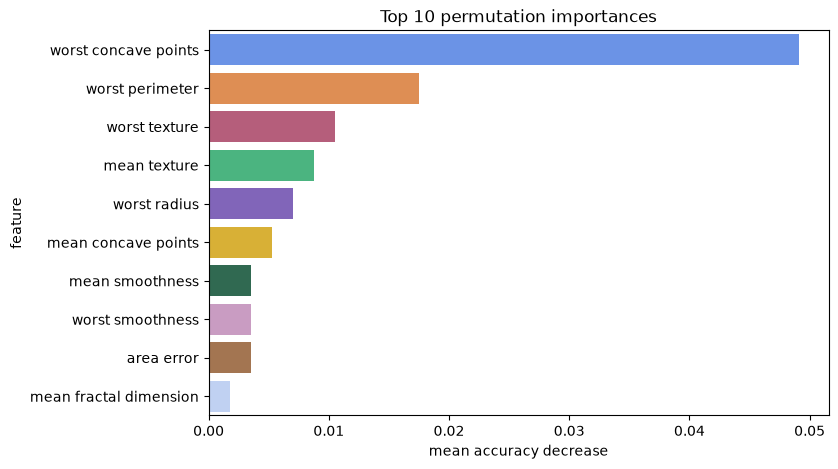

In [13]:
# permutation_importance()
# - 특정 feature 값을 섞었을 때 모델의 성능이 얼마나 떨어지는지를 계산함
# - 성능이 많이 떨어질수록 해당 feature가 예측에 중요하게 사용되고 있다고 해석
perm_result = permutation_importance(
    hist_clf,
    boost_X_test,
    boost_y_test,

    # feature를 섞는 실험을 몇 번 반복할지 지정
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

# importances_mean: feature를 섞었을 때 평균적으로 감소한 성능
# importances_std: 반복 실험에서 중요도가 얼마나 흔들렸는지 나타내는 표준편차
perm_importance_df = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

# 중요도 상위 10개 feature만 먼저 확인함.
display(perm_importance_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=perm_importance_df.head(10),
    x='importance_mean',
    y='feature',
    hue='feature',
    legend=False
)
plt.title('Top 10 permutation importances')
plt.xlabel('mean accuracy decrease')
plt.ylabel('feature')
plt.show()

# 막대가 길수록 해당 feature가 섞였을 때 accuracy 감소량이 컸다는 뜻.
# -> feature의 중요가 높다고 해서 분류/예측의 직접적인 원인은 아니다!

## 09. Gradient Boosting 회귀 모델

- Boosting은 회귀 문제에도 사용할 수 있음.
- 회귀에서는 이전 모델의 예측 오차를 줄이는 방향으로 다음 모델이 추가됨.
- R2는 클수록 좋고, RMSE는 작을수록 좋음.


In [14]:
diabetes = load_diabetes(as_frame=True)
reg_X = diabetes.data
reg_y = diabetes.target

print('회귀 feature shape:', reg_X.shape)
print('회귀 target shape:', reg_y.shape)
display(reg_X.head())


회귀 feature shape: (442, 10)
회귀 target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [15]:

reg_X_train, reg_X_test, reg_y_train, reg_y_test = train_test_split(
    reg_X,
    reg_y,
    test_size=0.2,
    random_state=42
)

# GradientBoosting: 이전 모델의 오차를 다음 모델이 보정
gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

# HistGradientBoosting: 구간화 기반으로 빠르게 학습하는 GradientBoosting
hist_gb_reg = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

reg_results = []
for name, model in {
    'gradient_boosting': gb_reg,
    'hist_gradient_boosting': hist_gb_reg}.items():

    model.fit(reg_X_train, reg_y_train)
    pred = model.predict(reg_X_test)

    reg_results.append({
        'model': name,
        # score(): 회귀 모델에서는 R2 결정계수를 반환함. 1에 가까울수록 설명력이 높음.
        'train_R2': model.score(reg_X_train, reg_y_train),
        'test_R2': r2_score(reg_y_test, pred),
        # RMSE: 예측값이 실제값에서 평균적으로 얼마나 벗어나는지 원래 target 단위로 보여줌. 낮을수록 좋음.
        'test_RMSE': root_mean_squared_error(reg_y_test, pred)
    })

# 모델별 성능을 표로 모아 비교함.
display(pd.DataFrame(reg_results))


,model,train_R2,test_R2,test_RMSE
0,gradient_boosting,0.716236,0.472384,52.871462
1,hist_gradient_boosting,0.690380,0.492951,51.830706


## 10. Boosting 정리

- Boosting은 약한 모델을 순차적으로 학습해 앞 모델의 실수를 뒤 모델이 보완하는 방식임.
- AdaBoost는 틀린 샘플에 더 큰 가중치를 주는 방식으로 설명할 수 있음.
- Gradient Boosting은 오차를 줄이는 방향으로 다음 모델을 추가함.
- `learning_rate`와 `n_estimators`는 함께 조절해야 함.
- Boosting은 강력하지만 설정에 따라 과대적합될 수 있으므로 검증 점수를 함께 확인해야 함.
